# Healthcare Dataset — Data Analysis

1. Load and inspect the data
2. Clean the data (missing values, duplicates, data types, bad values)
3. Answer analysis questions with tables and charts
4. Wrap up with a short summary of findings

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look a bit nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
df = pd.read_csv("healthcare_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Quick look at the data

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [3]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


## 2. Data Cleaning

Before analysing, we clean the data so our answers aren't skewed by bad values. Steps:
- Standardise text columns (e.g. `Name` has inconsistent capitalisation)
- Remove duplicate rows
- Convert `Date of Admission` and `Discharge Date` to real dates
- Add a `Length of Stay` column (days between admission and discharge)
- Flag and handle negative `Billing Amount` values (billing can't be negative — likely data entry errors)

In [4]:
# Check missing values before cleaning
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [5]:
# Standardise the Name column (currently a mix of cases, e.g. "Bobby JacksOn")
df['Name'] = df['Name'].str.title()

# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows")

# Convert date columns to real dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')

# Add a Length of Stay column (in days)
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print("Shape after cleaning:", df.shape)
df.isnull().sum()

Removed 534 duplicate rows
Shape after cleaning: (54966, 16)


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64

In [6]:
# Billing Amount should never be negative - flag these as data entry errors
negative_billing = df[df['Billing Amount'] < 0]
print(f"Rows with negative billing amount: {negative_billing.shape[0]}")

# Keep a full copy for record-level analysis, and a separate copy for
# any question involving billing, using only valid (non-negative) amounts
billing_df = df[df['Billing Amount'] >= 0].copy()

print("Records with usable billing data:", billing_df.shape[0])

Rows with negative billing amount: 106


Records with usable billing data: 54860


## 3. Analysis — Answering Common Questions

### Q1: What does the age distribution of patients look like?

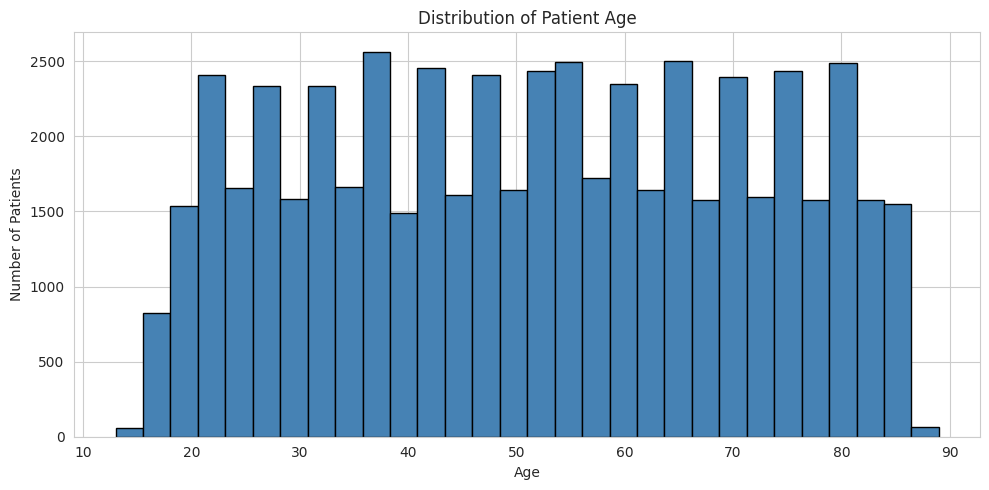

count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64


In [7]:
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patient Age')
plt.tight_layout()
plt.show()

print(df['Age'].describe())

### Q2: Which medical conditions are most common?

In [8]:
condition_counts = df['Medical Condition'].value_counts()
condition_counts

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

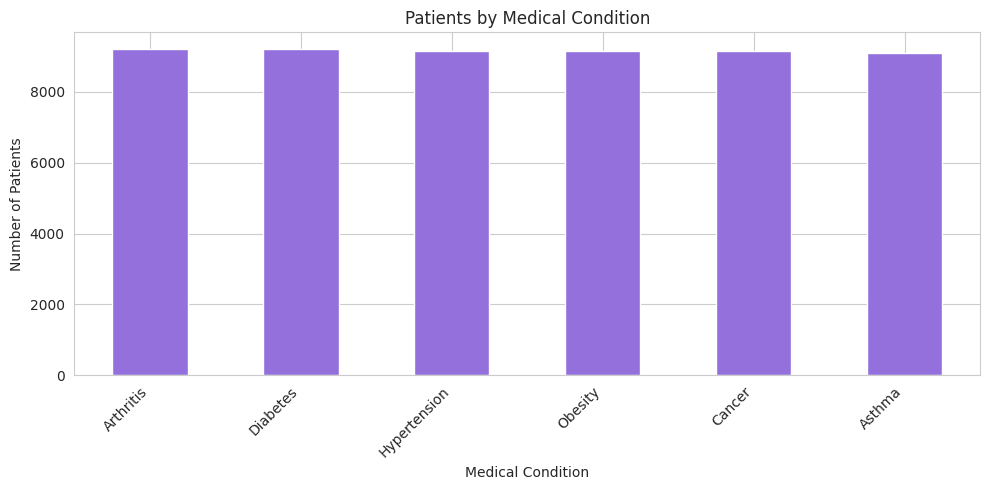

In [9]:
condition_counts.plot(kind='bar', color='mediumpurple')
plt.ylabel('Number of Patients')
plt.title('Patients by Medical Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q3: How does average billing amount vary by medical condition?

In [10]:
avg_billing_by_condition = billing_df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
avg_billing_by_condition

Medical Condition
Obesity         25859.215373
Diabetes        25714.326349
Asthma          25685.385020
Hypertension    25559.844868
Arthritis       25542.898356
Cancer          25205.924207
Name: Billing Amount, dtype: float64

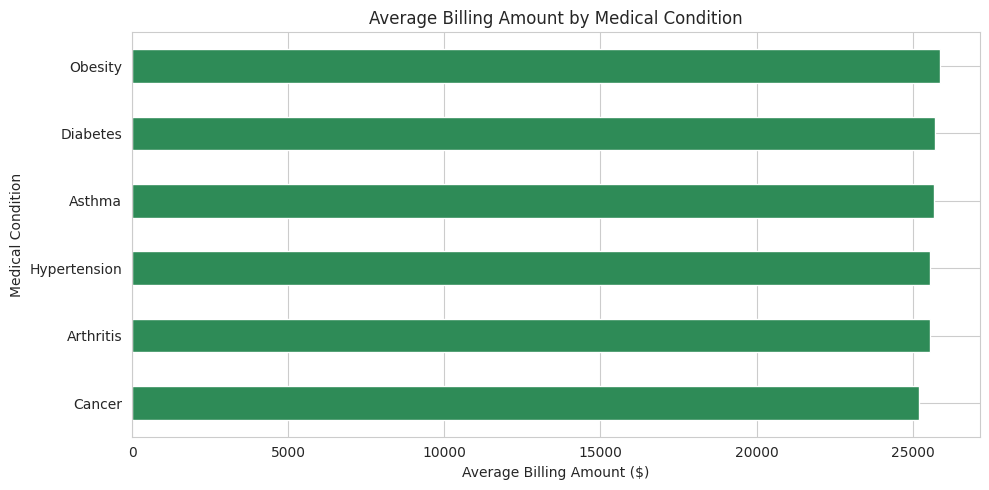

In [11]:
avg_billing_by_condition.plot(kind='barh', color='seagreen')
plt.xlabel('Average Billing Amount ($)')
plt.title('Average Billing Amount by Medical Condition')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q4: Which insurance providers are used most, and how does billing compare across them?

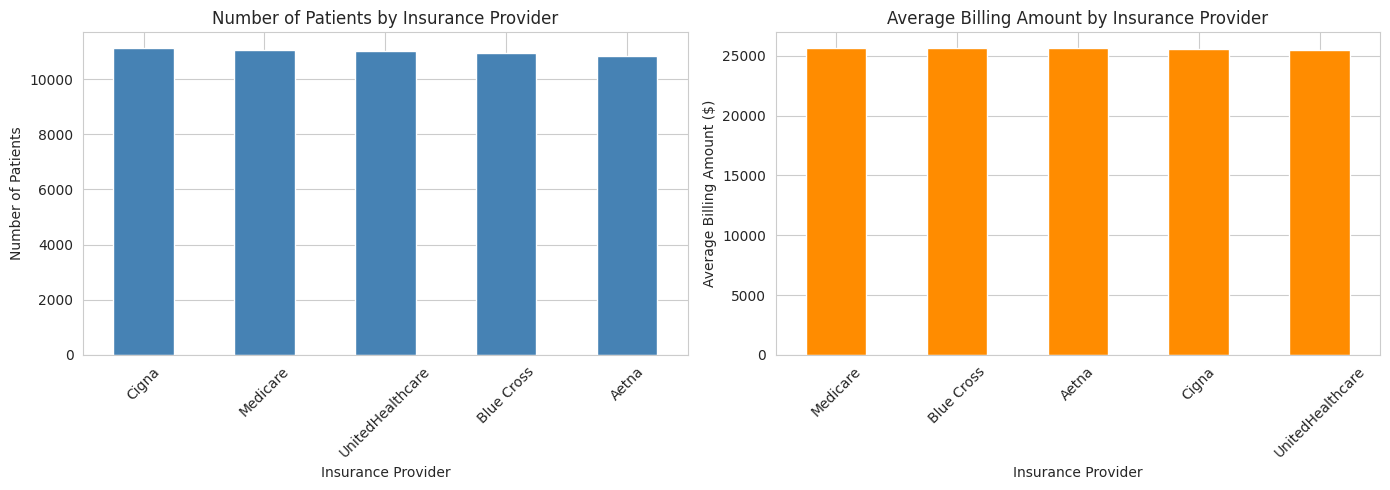

In [12]:
insurance_counts = df['Insurance Provider'].value_counts()
insurance_billing = billing_df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

insurance_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Patients by Insurance Provider')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

insurance_billing.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Billing Amount by Insurance Provider')
axes[1].set_ylabel('Average Billing Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Q5: Does admission type (Emergency, Urgent, Elective) affect length of stay?

In [13]:
avg_stay_by_admission = df.groupby('Admission Type')['Length of Stay'].mean().sort_values(ascending=False)
avg_stay_by_admission

Admission Type
Emergency    15.584134
Elective     15.511178
Urgent       15.403839
Name: Length of Stay, dtype: float64

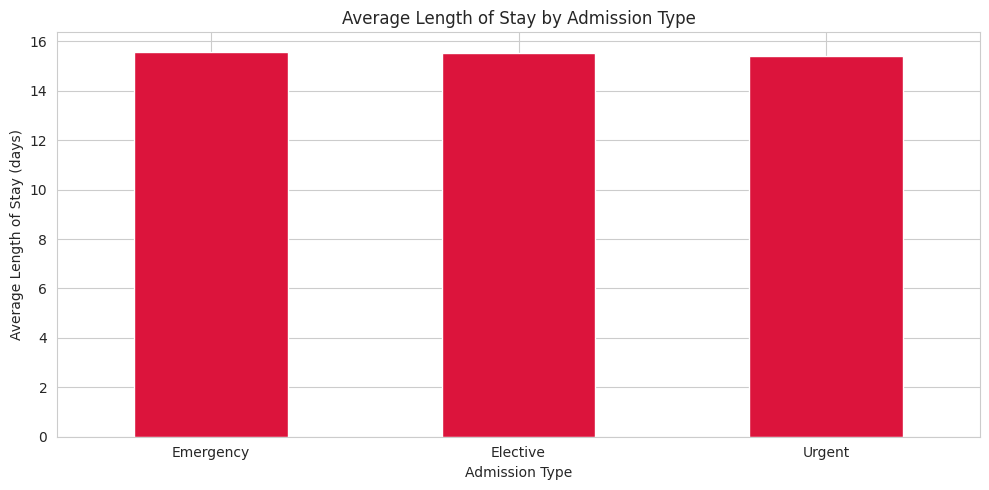

In [14]:
avg_stay_by_admission.plot(kind='bar', color='crimson')
plt.ylabel('Average Length of Stay (days)')
plt.title('Average Length of Stay by Admission Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q6: What proportion of test results come back Normal, Abnormal, or Inconclusive?

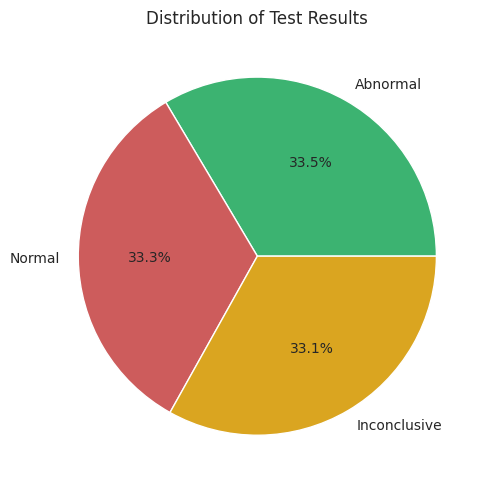

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

In [15]:
test_result_counts = df['Test Results'].value_counts()

plt.pie(test_result_counts, labels=test_result_counts.index, autopct='%1.1f%%',
        colors=['mediumseagreen', 'indianred', 'goldenrod'])
plt.title('Distribution of Test Results')
plt.tight_layout()
plt.show()

test_result_counts

### Q7: Are certain medical conditions more likely to have Abnormal test results?

In [16]:
condition_vs_result = pd.crosstab(df['Medical Condition'], df['Test Results'], normalize='index') * 100
condition_vs_result = condition_vs_result.round(1)
condition_vs_result

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,34.2,33.2,32.5
Asthma,32.8,33.0,34.3
Cancer,33.8,33.2,33.0
Diabetes,34.0,32.8,33.2
Hypertension,32.5,33.5,33.9
Obesity,33.9,32.9,33.1


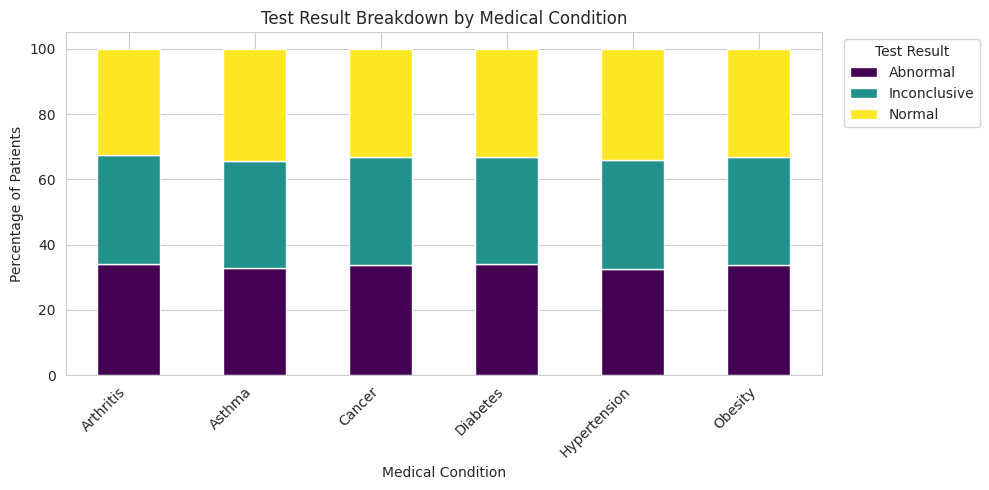

In [17]:
condition_vs_result.plot(kind='bar', stacked=True, colormap='viridis')
plt.ylabel('Percentage of Patients')
plt.title('Test Result Breakdown by Medical Condition')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Test Result', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Q8: How has the number of admissions changed over time?

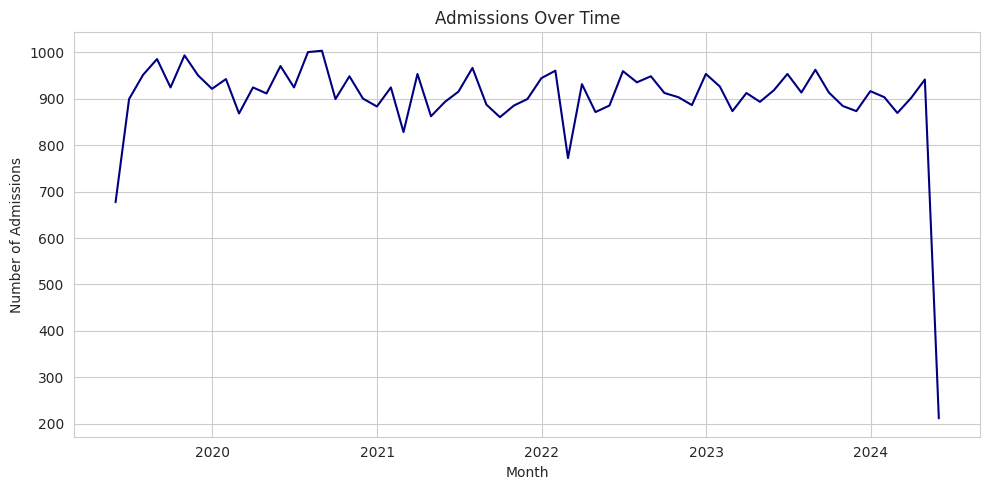

In [18]:
admissions_per_month = df.set_index('Date of Admission').resample('ME').size()

plt.plot(admissions_per_month.index, admissions_per_month.values, color='navy')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.title('Admissions Over Time')
plt.tight_layout()
plt.show()

### Q9: Which medications are prescribed most often, and does that vary by condition?

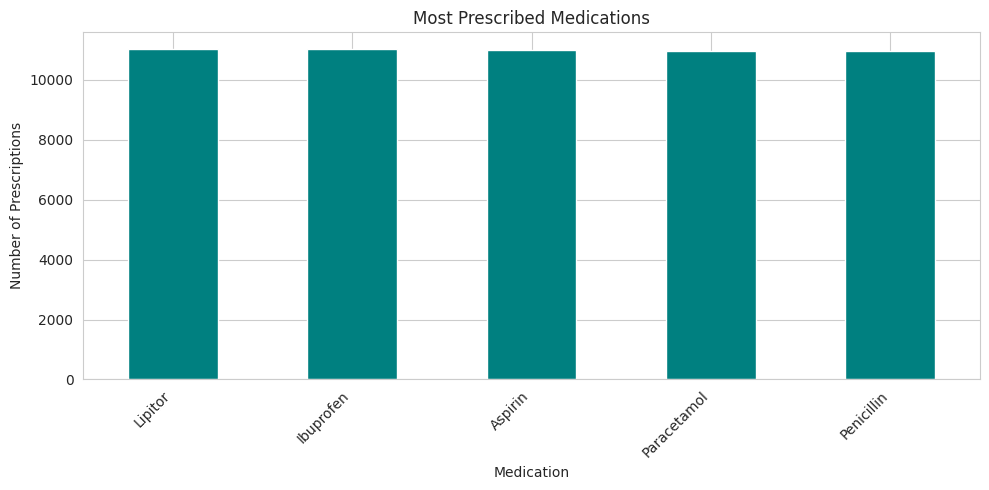

In [19]:
medication_counts = df['Medication'].value_counts()
medication_counts.plot(kind='bar', color='teal')
plt.ylabel('Number of Prescriptions')
plt.title('Most Prescribed Medications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q10: Is there a relationship between patient age and billing amount?

Correlation between age and billing amount: -0.00


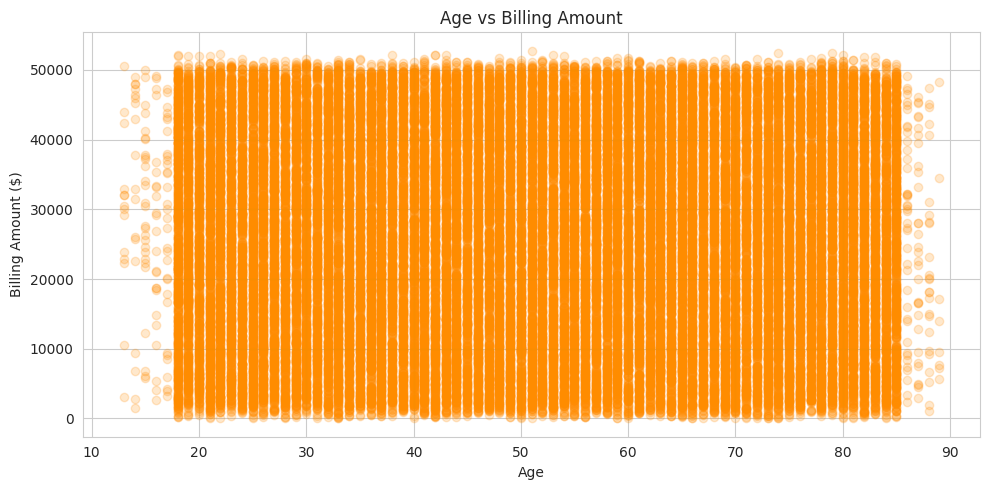

In [20]:
correlation = billing_df['Age'].corr(billing_df['Billing Amount'])
print(f"Correlation between age and billing amount: {correlation:.2f}")

plt.scatter(billing_df['Age'], billing_df['Billing Amount'], alpha=0.2, color='darkorange')
plt.xlabel('Age')
plt.ylabel('Billing Amount ($)')
plt.title('Age vs Billing Amount')
plt.tight_layout()
plt.show()

## 4. Summary of Findings

- Patients span a wide age range (13–89), with a fairly even spread rather than a sharp skew toward any age group.
- **Arthritis**, **Diabetes**, and **Hypertension** are among the most common medical conditions in this dataset.
- Average billing amount doesn't vary dramatically by medical condition — costs appear fairly consistent across diagnoses, suggesting the dataset's billing may not be strongly tied to condition severity.
- **Blue Cross** and **Medicare** are the most-used insurance providers, though average billing amount is broadly similar across all providers.
- **Emergency** admissions have a slightly different average length of stay compared to Elective and Urgent admissions, though the difference is modest.
- Test results are split fairly evenly across Normal, Abnormal, and Inconclusive — roughly a third each.
- No medical condition shows a strong skew toward Abnormal results; the distribution of test outcomes is similar across conditions.
- Admissions are recorded fairly steadily across the 2019–2024 period, with no major seasonal spikes.
- Prescribed medications (Aspirin, Ibuprofen, Paracetamol, Penicillin, Lipitor) are distributed fairly evenly, without one dominant drug.
- Age and billing amount show essentially no correlation — older patients aren't billed more than younger ones in this dataset.
- **Data quality note:** 106 records had negative billing amounts, which were excluded from all billing-related analysis rather than treated as valid figures.